Import the libraries.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

Read the dataset.

In [28]:
df = pd.read_csv("Datasets/cgpa-package.csv")
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Plot of the data.

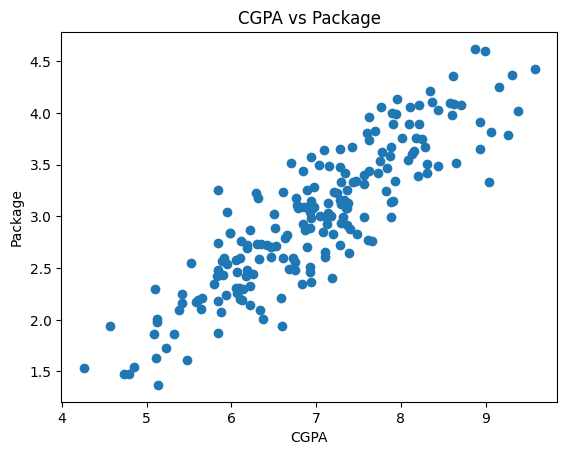

In [29]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package')
plt.title('CGPA vs Package')
plt.show()

Train test split.

In [30]:
x = df['cgpa']
y = df['package']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train = x_train.values.reshape(-1, 1)
x_test = x_test.values.reshape(-1, 1)


Train the model using linear regression of sklearn library.

In [31]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((160, 1), (40, 1), (160,), (40,))

In [33]:
lr.predict(x_test)

array([2.78031348, 3.13635249, 3.1995207 , 2.38981908, 3.52684689,
       3.76803461, 3.16506531, 2.54486832, 3.17655044, 3.4923915 ,
       1.90744364, 2.34962112, 3.6876387 , 2.75734322, 3.47516381,
       3.04447145, 2.32665086, 3.20526327, 2.17734418, 3.314372  ,
       2.45298729, 2.90090734, 3.32011456, 2.87219451, 3.33734226,
       2.19457187, 1.41932564, 2.7114027 , 3.18229301, 2.32665086,
       3.74506435, 2.95833298, 3.68189614, 2.97556068, 2.59080884,
       3.34882738, 2.47595755, 3.07318428, 4.17575671, 2.95833298])

Draw the best fit line.

Text(0, 0.5, 'Package(in lpa)')

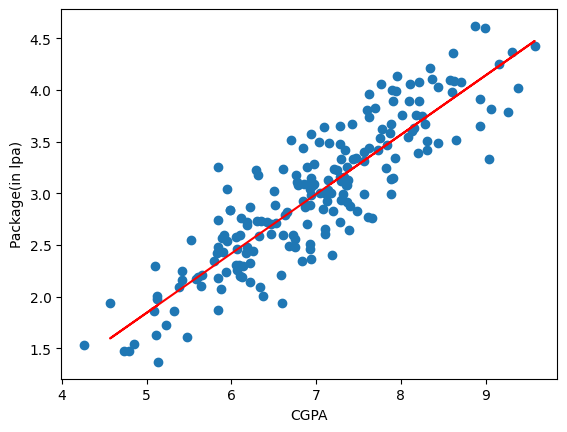

In [34]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(x_train,lr.predict(x_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

Find the m and c of the best fit line.

In [35]:
m = lr.coef_
c = lr.intercept_
m,c

(array([0.57425647]), np.float64(-1.0270069374542108))

In [36]:
# y = mx + c
m * 100 + c

array([56.39864033])

Making our own linear regression class and train model on that.

In [37]:
class SelfMadeLR:

    def __init__(self):
        self.m = None
        self.c = None

    def fit(self, x_train, y_train):
        n = len(x_train)
        x_mean = np.mean(x_train)
        y_mean = np.mean(y_train)

        num = 0
        den = 0

        for i in range(n):
            num += (x_train[i] - x_mean) * (y_train[i] - y_mean)
            den += (x_train[i] - x_mean) ** 2

        self.m = num / den
        self.c = y_mean - self.m * x_mean

    def predict(self, x_test):
        return self.m * x_test + self.c

In [42]:
x_train2, x_test2, y_train2, y_test2 = train_test_split(x, y, test_size=0.2, random_state=2)
x_train2 = x_train2.values
y_train2 = y_train2.values

In [43]:
lr = SelfMadeLR()
lr.fit(x_train2, y_train2)

In [44]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((160, 1), (40, 1), (160,), (40,))

In [45]:
x_train.mean()

np.float64(7.005375000000001)

In [47]:
lr.predict(x_test2)

112    3.891116
29     3.093245
182    2.384646
199    2.574349
193    1.653729
85     1.776478
10     2.072193
54     2.931439
115    3.762787
35     2.937018
12     4.091979
92     3.511709
13     2.970495
126    2.401384
174    3.188097
2      3.467073
44     1.943864
3      3.243892
113    2.976075
14     3.416857
23     2.557611
25     3.165778
6      2.858905
134    3.121142
165    3.684674
173    2.870064
45     3.494970
65     3.344323
48     3.919014
122    1.960602
178    3.651197
64     3.210415
9      3.740469
57     2.786371
78     2.780792
71     3.271789
128    3.528447
176    2.613406
131    2.658042
53     2.713837
Name: cgpa, dtype: float64